In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier 
from sklearn.linear_model import LogisticRegression 
from sklearn.model_selection import train_test_split 
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve 
from sklearn.ensemble import RandomForestClassifier 


In [2]:
df = pd.read_csv('train.csv')
df = df[['Pclass', 'Sex', 'Age', 'Fare', 'Survived', 'Parch', 'SibSp']]
df.dropna(inplace=True)

#convert sex to numbers 0-1
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(df.shape)
print(df.isnull().sum())
df.head(10)

(714, 7)
Pclass      0
Sex         0
Age         0
Fare        0
Survived    0
Parch       0
SibSp       0
dtype: int64


,Pclass,Sex,Age,Fare,Survived,Parch,SibSp
0,3,0,22.0,7.2500,0,0,1
1,1,1,38.0,71.2833,1,0,1
2,3,1,26.0,7.9250,1,0,0
3,1,1,35.0,53.1000,1,0,1
4,3,0,35.0,8.0500,0,0,0
6,1,0,54.0,51.8625,0,0,0
7,3,0,2.0,21.0750,0,1,3
8,3,1,27.0,11.1333,1,2,0
9,2,1,14.0,30.0708,1,0,1
10,3,1,4.0,16.7000,1,1,1


In [3]:
#train/test split  

x =df.drop(columns='Survived')
y = df['Survived']

#train split test 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

Model Trained Successfully
Accuracy: 0.7483
ROC-AUC: 0.8164


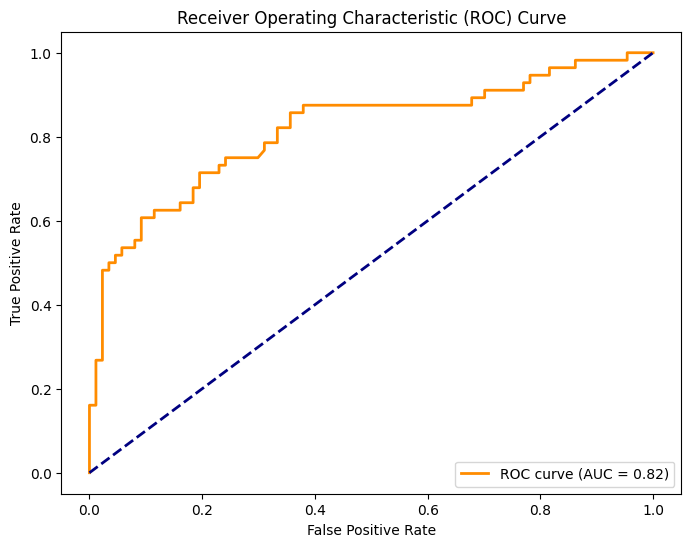

In [4]:
#train the model (logistic regression)

model = LogisticRegression()
model.fit(x_train, y_train)

print("Model Trained Successfully")

#prediction 
y_pred = model.predict(x_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.4f}")

#ROC and AUC 

y_proba = model.predict_proba(x_test)[:, 1]
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {roc_auc:.4f}")

#plot 

fpr, tpr, thresholds = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.show()


In [5]:
#Store best decision tree

best_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
best_tree.fit(x_train, y_train)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at 

Model Trained Successfully
Train AUC: 0.9995
Test AUC: 0.8056
Pclass: 0.0816
Sex: 0.2752
Age: 0.2882
Fare: 0.2762
Parch: 0.0364
SibSp: 0.0424


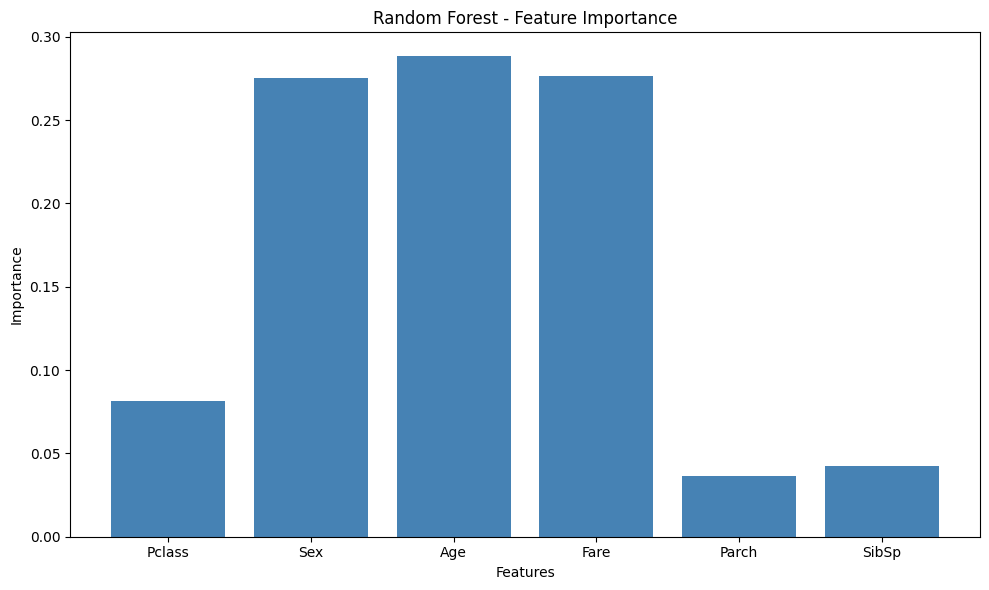

In [11]:
model_rf = RandomForestClassifier(n_estimators = 100, random_state = 42)
model_rf.fit(x_train, y_train)

print("Model Trained Successfully")

train_auc = roc_auc_score(y_train, model_rf.predict_proba(x_train)[:, 1])
test_auc = roc_auc_score(y_test, model_rf.predict_proba(x_test)[:, 1])
print(f"Train AUC: {train_auc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

importances = model_rf.feature_importances_
feature_names = x.columns
for name, importance in zip(feature_names, importances):
    print(f"{name}: {importance:.4f}")


#plot bar chart 

plt.figure(figsize=(10, 6))
plt.bar(feature_names, importances, color='steelblue')
plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Random Forest - Feature Importance")
plt.tight_layout()
plt.show()
